# Exploring generation of a CDK9 tiling mutagenesis library

Goal is to explore mechanisms of resistance to CDK9 inhibitors via tiling mutagenesis of CDK9 with base editing.

In [31]:
import numpy as np
import gffutils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
from pegg import prime
import Bio.Seq

In [27]:
#GRCh38 database
db = gffutils.FeatureDB('/Users/samgould/Desktop/FSR Lab/reference files/gencode_v44_GRCh38.db', keep_order=True)

#accessed genome annotations using gffutils package
#canonical MANE transcript for CDK9 (CDK9-201)
tx = 'ENST00000373264.5'

cds = list(db.children(tx, order_by='+end', featuretype=['CDS']))
start_end_cds = [[i.start, i.end] for i in cds]
strand = db[tx].strand
chrom = db[tx].chrom
print(chrom)
print(strand)
print(db[tx].attributes)


chr9
+
gene_id: ['ENSG00000136807.14']
transcript_id: ['ENST00000373264.5']
gene_type: ['protein_coding']
gene_name: ['CDK9']
transcript_type: ['protein_coding']
transcript_name: ['CDK9-201']
level: ['2']
protein_id: ['ENSP00000362361.4']
transcript_support_level: ['1']
hgnc_id: ['HGNC:1780']
tag: ['basic', 'Ensembl_canonical', 'MANE_Select', 'appris_principal_1', 'CCDS']
ccdsid: ['CCDS6879.1']
havana_gene: ['OTTHUMG00000020715.4']
havana_transcript: ['OTTHUMT00000054235.2']


In [16]:
filepath = '/Users/samgould/Desktop/FSR Lab/reference files/GRCh38/ncbi-genomes-2022-02-23/GCF_000001405.26_GRCh38_genomic.fna.gz'
chrom_dict, i = prime.genome_loader(filepath)

In [29]:
chr9 = chrom_dict[9]

transcript = ''
for i in start_end_cds:
    s = i[0]-1
    e = i[1]
    transcript+=chr9[s:e]


In [35]:
WT = 'MAKQYDSVECPFCDEVSKYEKLAKIGQGTFGEVFKARHRKTGQKVALKKVLMENEKEGFPITALREIKILQLLKHENVVNLIEICRTKASPYNRCKGSIYLVFDFCEHDLAGLLSNVLVKFTLSEIKRVMQMLLNGLYYIHRNKILHRDMKAANVLITRDGVLKLADFGLARAFSLAKNSQPNRYTNRVVTLWYRPPELLLGERDYGPPIDLWGAGCIMAEMWTRSPIMQGNTEQHQLALISQLCGSITPEVWPNVDNYELYEKLELVKGQKRKVKDRLKAYVRDPYALDLIDKLLVLDPAQRIDSDDALNHDFFWSDPMPSDLKGMLSTHLTSMFEYLAPPRRKGSQITQQSTNQSRNPATTNQTEFERVF'

WT == str(Bio.Seq.Seq(transcript).transcribe().translate())

True

In [37]:
start_end_cds_recentered = []
buffer = 50
for k in start_end_cds:
    h = []
    for j in k:
        h.append(j-127786149+buffer)
    start_end_cds_recentered.append(h)

start_end_cds_recentered

[[50, 141],
 [602, 683],
 [1419, 1509],
 [1848, 2014],
 [2115, 2286],
 [2445, 2593],
 [3079, 3441]]

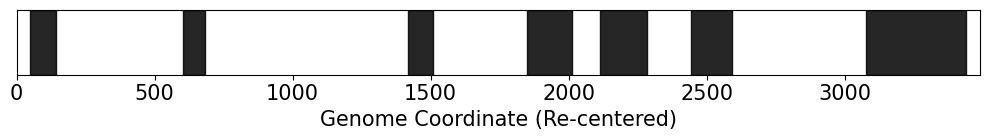

In [39]:


amp_locs = start_end_cds_recentered

mat1 = np.zeros(3441+50)

fig, ax = plt.subplots(figsize=(10,1.5))

for i in amp_locs:

    ax.axvspan(i[0],i[1], alpha=0.85, color='black')

ax.set_xlim(0,3441+50)
ax.set_yticks([])
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Genome Coordinate (Re-centered)', fontsize=15)

fig.tight_layout()

In [40]:
#including 20 nt buffer on either side of exon for generating PAM sequences

start_end_cds_20 = []
buffer = 20
for k in start_end_cds:
    h = []
    for idx, j in enumerate(k):
        if idx==0:
            h.append(j-buffer)
        if idx==1:
            h.append(j+buffer)
    start_end_cds_20.append(h)

start_end_cds_20

[[127786129, 127786260],
 [127786681, 127786802],
 [127787498, 127787628],
 [127787927, 127788133],
 [127788194, 127788405],
 [127788524, 127788712],
 [127789158, 127789560]]

In [125]:
chr9 = chrom_dict[9]

plus_count = 0
minus_count = 0

plus_pam_loc_start = []
plus_pam_loc_end = []
PAM_plus = []
plus_protospacer = []
plus_proto_start = []
plus_proto_end = []
plus_ideal_start = []
plus_ideal_end = []
plus_ideal_window = []
plus_exon_list = []

minus_pam_loc_start = []
minus_pam_loc_end = []
PAM_minus = []
minus_protospacer = []
minus_proto_start = []
minus_proto_end = []
minus_ideal_start = []
minus_ideal_end = []
minus_ideal_window = []
minus_exon_list = []

exon_list = [1,2,3,4,5,6,7]

for idx1, i in enumerate(start_end_cds_20):
    s = i[0]-1
    e = i[1]

    sub_chrom=str(chr9[s:e]).upper()
    print(sub_chrom)
    loc_list = list(range(s, e))

    for idx, k in enumerate(sub_chrom):
        #first deal with the plus strand
        if k=='G':
            
            if idx-20 >=0:
                plus_count+=1
                plus_pam_loc_start.append(loc_list[idx])
                plus_pam_loc_end.append(loc_list[idx]+1)

                PAM_plus.append(str(chr9[loc_list[idx]-1:loc_list[idx]+1]).upper())
                
                proto_start = loc_list[idx]-21
                proto_end = loc_list[idx]-1
                proto = str(chr9[proto_start: proto_end]).upper()
                plus_protospacer.append(proto)
                plus_proto_start.append(proto_start+1)
                plus_proto_end.append(proto_end)

                #and ideal editing window
                plus_ideal_start.append(proto_start+3+1)
                plus_ideal_end.append(proto_start+8)
                plus_ideal_window.append(str(chr9[proto_start+3: proto_start+8]).upper())
                plus_exon_list.append(exon_list[idx1])

        #then the minus strand
        if k=='C':

            if idx+20<=len(sub_chrom):
                minus_count+=1

                minus_pam_loc_end.append(loc_list[idx])
                minus_pam_loc_start.append(loc_list[idx]+1)

                PAM_minus.append(str(chr9[loc_list[idx]:loc_list[idx]+2].reverse_complement()).upper())

                proto_end = loc_list[idx]+2
                proto_start = loc_list[idx] + 22
                proto = str(chr9[proto_end: proto_start].reverse_complement()).upper()

                minus_protospacer.append(proto)
                minus_proto_start.append(proto_start)
                minus_proto_end.append(proto_end+1)

                #and ideal editing window
                minus_ideal_start.append(proto_start-3)
                minus_ideal_end.append(proto_start-8+1)
                minus_ideal_window.append(str(chr9[proto_start-8: proto_start-3].reverse_complement()).upper())
                minus_exon_list.append(exon_list[idx1])
                


GCGGCGCGTTGGAGGCGGCCATGGCAAAGCAGTACGACTCGGTGGAGTGCCCTTTTTGTGATGAAGTTTCCAAATACGAGAAGCTCGCCAAGATCGGCCAAGGCACCTTCGGGTAAGGCTGGGCCCCTCGGG
GTCTCCCTTTCCGCCTGCAGGGAGGTGTTCAAGGCCAGGCACCGCAAGACCGGCCAGAAGGTGGCTCTGAAGAAGGTGCTGATGGAAAACGAGAAGGAGGGGGTGAGTACGGATCGGGCGTG
TTCCCCTCTTTCTCACCCAGTTCCCCATTACAGCCTTGCGGGAGATCAAGATCCTTCAGCTTCTAAAACACGAGAATGTGGTCAACTTGATTGAGATTTGTCGAACCAAAGGTAAGTTATTTGGTTCTTAC
TCTTTCTATTCCTGCCTCAGCTTCCCCCTATAACCGCTGCAAGGGTAGTATATACCTGGTGTTCGACTTCTGCGAGCATGACCTTGCTGGGCTGTTGAGCAATGTTTTGGTCAAGTTCACGCTGTCTGAGATCAAGAGGGTGATGCAGATGCTGCTTAACGGCCTCTACTACATCCACAGAAACAAGGTGGGGGCCAGAGCTGGGAG
CACTCTTGCCCTTCCTGCAGATCCTGCATAGGGACATGAAGGCTGCTAATGTGCTTATCACTCGTGATGGGGTCCTGAAGCTGGCAGACTTTGGGCTGGCCCGGGCCTTCAGCCTGGCCAAGAACAGCCAGCCCAACCGCTACACCAACCGTGTGGTGACACTCTGGTACCGGCCCCCGGAGCTGTTGCTCGGTGAGGACTCCCGAGCGGGC
TGGTGCGCTCTTCTTCCCAGGGGAGCGGGACTACGGCCCCCCCATTGACCTGTGGGGTGCTGGGTGCATCATGGCAGAGATGTGGACCCGCAGCCCCATCATGCAGGGCAACACGGAGCAGCACCAACTCGCCCTCATCAGTCAGCTCTGCGGCTCCATCACCCCTGAGGTACGGGGCCCCGGTCCCCA
C

In [126]:
col_names = ['protospacer', 'exon', 'proto_start', 'proto_end', 'PAM', 'PAM_start', 'PAM_end', 'ideal_start', 'ideal_end', 'ideal_window']

cols = [plus_protospacer, plus_exon_list, plus_proto_start,plus_proto_end,PAM_plus,plus_pam_loc_start,plus_pam_loc_end, plus_ideal_start, plus_ideal_end, plus_ideal_window ]
plus_df = pd.DataFrame(dict(zip(col_names, cols)))
plus_df['strand'] = '+'


cols_minus = [minus_protospacer, minus_exon_list, minus_proto_start,minus_proto_end,PAM_minus,minus_pam_loc_start,minus_pam_loc_end, minus_ideal_start, minus_ideal_end, minus_ideal_window ]

minus_df = pd.DataFrame(dict(zip(col_names, cols_minus)))
minus_df['strand'] = '-'
minus_df

,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,ideal_start,ideal_end,ideal_window,strand
0,CATGGCCGCCTCCAACGCGC,1,127786151,127786132,CG,127786130,127786129,127786148,127786144,GGCCG,-
1,TGCCATGGCCGCCTCCAACG,1,127786154,127786135,CG,127786133,127786132,127786151,127786147,CATGG,-
2,TTTGCCATGGCCGCCTCCAA,1,127786156,127786137,CG,127786135,127786134,127786153,127786149,GCCAT,-
3,TCGTACTGCTTTGCCATGGC,1,127786165,127786146,CG,127786144,127786143,127786162,127786158,TACTG,-
4,GAGTCGTACTGCTTTGCCAT,1,127786168,127786149,GG,127786147,127786146,127786165,127786161,TCGTA,-
...,...,...,...,...,...,...,...,...,...,...,...
383,CAGAAGACGCGCTCAAACTC,7,127789542,127789523,CG,127789521,127789520,127789539,127789535,AAGAC,-
384,GCGCCGGCCCTCAGAAGACG,7,127789553,127789534,CG,127789532,127789531,127789550,127789546,CCGGC,-
385,AAGCGCCGGCCCTCAGAAGA,7,127789555,127789536,CG,127789534,127789533,127789552,127789548,CGCCG,-
386,GGCAAGCGCCGGCCCTCAGA,7,127789558,127789539,AG,127789537,127789536,127789555,127789551,AAGCG,-


In [127]:
minus_df

,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,ideal_start,ideal_end,ideal_window,strand
0,CATGGCCGCCTCCAACGCGC,1,127786151,127786132,CG,127786130,127786129,127786148,127786144,GGCCG,-
1,TGCCATGGCCGCCTCCAACG,1,127786154,127786135,CG,127786133,127786132,127786151,127786147,CATGG,-
2,TTTGCCATGGCCGCCTCCAA,1,127786156,127786137,CG,127786135,127786134,127786153,127786149,GCCAT,-
3,TCGTACTGCTTTGCCATGGC,1,127786165,127786146,CG,127786144,127786143,127786162,127786158,TACTG,-
4,GAGTCGTACTGCTTTGCCAT,1,127786168,127786149,GG,127786147,127786146,127786165,127786161,TCGTA,-
...,...,...,...,...,...,...,...,...,...,...,...
383,CAGAAGACGCGCTCAAACTC,7,127789542,127789523,CG,127789521,127789520,127789539,127789535,AAGAC,-
384,GCGCCGGCCCTCAGAAGACG,7,127789553,127789534,CG,127789532,127789531,127789550,127789546,CCGGC,-
385,AAGCGCCGGCCCTCAGAAGA,7,127789555,127789536,CG,127789534,127789533,127789552,127789548,CGCCG,-
386,GGCAAGCGCCGGCCCTCAGA,7,127789558,127789539,AG,127789537,127789536,127789555,127789551,AAGCG,-


In [130]:
chr9[127786144-1:127786148].reverse_complement().upper()

Seq('GGCCG')

# filter out guides that don't hit CDS

NEED TO BE MINDFUL OF THE 0-based indexing here...the coordinates are likely off by 1 in the dataframe that I generated. Need to regenerate this. (fixed this for the plus_df but not the minus df)

keep splice variants?

determine the possible amino acid changes based on ideal editing window of +4 to +8

and also plot out the full map of the mutagenesis tiling screen


In [135]:
#filter out guides whose ideal editing window doesn't hit in an exon
cds_hit = []
for i, val in plus_df.iterrows():
    ideal_start = val['ideal_start']
    ideal_end = val['ideal_end']-1
    
    hit=False
    for k in start_end_cds:
        exon_coords = list(range(k[0], k[1]+1))
        if ideal_start in exon_coords:
            hit=True
        if ideal_end in exon_coords:
            hit=True
        
    cds_hit.append(hit)

plus_df['CDS_hit'] = cds_hit

In [136]:
#filter out guides whose ideal editing window doesn't hit in an exon
cds_hit = []
for i, val in minus_df.iterrows():
    ideal_start = val['ideal_start']-1
    ideal_end = val['ideal_end']
    
    hit=False
    for k in start_end_cds:
        exon_coords = list(range(k[0], k[1]+1))
        if ideal_start in exon_coords:
            hit=True
        if ideal_end in exon_coords:
            hit=True
        
    cds_hit.append(hit)

minus_df['CDS_hit'] = cds_hit

In [137]:
minus_df[minus_df['CDS_hit']==True]

,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,ideal_start,ideal_end,ideal_window,strand,CDS_hit
1,TGCCATGGCCGCCTCCAACG,1,127786154,127786135,CG,127786133,127786132,127786151,127786147,CATGG,-,True
2,TTTGCCATGGCCGCCTCCAA,1,127786156,127786137,CG,127786135,127786134,127786153,127786149,GCCAT,-,True
3,TCGTACTGCTTTGCCATGGC,1,127786165,127786146,CG,127786144,127786143,127786162,127786158,TACTG,-,True
4,GAGTCGTACTGCTTTGCCAT,1,127786168,127786149,GG,127786147,127786146,127786165,127786161,TCGTA,-,True
5,CGAGTCGTACTGCTTTGCCA,1,127786169,127786150,TG,127786148,127786147,127786166,127786162,GTCGT,-,True
...,...,...,...,...,...,...,...,...,...,...,...,...
379,CGCTCAAACTCCGTCTGGTT,7,127789533,127789514,GG,127789512,127789511,127789530,127789526,TCAAA,-,True
380,GCGCTCAAACTCCGTCTGGT,7,127789534,127789515,TG,127789513,127789512,127789531,127789527,CTCAA,-,True
381,GACGCGCTCAAACTCCGTCT,7,127789537,127789518,GG,127789516,127789515,127789534,127789530,GCGCT,-,True
382,AGACGCGCTCAAACTCCGTC,7,127789538,127789519,TG,127789517,127789516,127789535,127789531,CGCGC,-,True


In [138]:
plus_df[plus_df['CDS_hit']==True]

,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,ideal_start,ideal_end,ideal_window,strand,CDS_hit
4,GCGGCCATGGCAAAGCAGTA,1,127786143,127786162,CG,127786163,127786164,127786146,127786150,GCCAT,+,True
5,CATGGCAAAGCAGTACGACT,1,127786148,127786167,CG,127786168,127786169,127786151,127786155,GGCAA,+,True
6,ATGGCAAAGCAGTACGACTC,1,127786149,127786168,GG,127786169,127786170,127786152,127786156,GCAAA,+,True
7,GGCAAAGCAGTACGACTCGG,1,127786151,127786170,TG,127786171,127786172,127786154,127786158,AAAGC,+,True
8,GCAAAGCAGTACGACTCGGT,1,127786152,127786171,GG,127786172,127786173,127786155,127786159,AAGCA,+,True
...,...,...,...,...,...,...,...,...,...,...,...,...
368,GTTTGAGCGCGTCTTCTGAG,7,127789525,127789544,GG,127789545,127789546,127789528,127789532,TGAGC,+,True
369,TGAGCGCGTCTTCTGAGGGC,7,127789528,127789547,CG,127789548,127789549,127789531,127789535,GCGCG,+,True
370,GAGCGCGTCTTCTGAGGGCC,7,127789529,127789548,GG,127789549,127789550,127789532,127789536,CGCGT,+,True
371,GCGCGTCTTCTGAGGGCCGG,7,127789531,127789550,CG,127789551,127789552,127789534,127789538,CGTCT,+,True


# simulating editing outcomes

In [460]:
WT_transcript_full = ''
for i in start_end_cds:
    s = i[0]-1
    e = i[1]
    WT_transcript_full+=chr9[s:e]

WT = 'MAKQYDSVECPFCDEVSKYEKLAKIGQGTFGEVFKARHRKTGQKVALKKVLMENEKEGFPITALREIKILQLLKHENVVNLIEICRTKASPYNRCKGSIYLVFDFCEHDLAGLLSNVLVKFTLSEIKRVMQMLLNGLYYIHRNKILHRDMKAANVLITRDGVLKLADFGLARAFSLAKNSQPNRYTNRVVTLWYRPPELLLGERDYGPPIDLWGAGCIMAEMWTRSPIMQGNTEQHQLALISQLCGSITPEVWPNVDNYELYEKLELVKGQKRKVKDRLKAYVRDPYALDLIDKLLVLDPAQRIDSDDALNHDFFWSDPMPSDLKGMLSTHLTSMFEYLAPPRRKGSQITQQSTNQSRNPATTNQTEFERVF'

WT == str(Bio.Seq.Seq(WT_transcript_full).transcribe().translate())

True

In [461]:
import itertools

def ABE_mutater(ideal_window):
    #count the As
    count_A = ideal_window.count('A')

    #generate all possible combinatoric mutation possibilities
    list_combs = []
    for i in range(1, count_A+1):

        list_combs+=list(itertools.combinations(range(count_A), i))

    #index the As
    l_key = []
    counter=0
    for i in ideal_window:
        if i=='A':
            l_key.append(counter)
            counter+=1
        else:
            l_key.append('None')

    #generate the mutated sequences
    mutated_ideal = []
    for i in list_combs:
        len_combination = len(i)

        mut_seq = ''
        #for k in i:
        for idx, base in enumerate(ideal_window):
            if l_key[idx] in i:
                mut_seq+='G'
            else:
                mut_seq+=base

        mutated_ideal.append(mut_seq)

    return mutated_ideal

def CBE_mutater(ideal_window):
    #count the As
    count_C = ideal_window.count('C')

    #generate all possible combinatoric mutation possibilities
    list_combs = []
    for i in range(1, count_C+1):

        list_combs+=list(itertools.combinations(range(count_C), i))

    #index the As
    l_key = []
    counter=0
    for i in ideal_window:
        if i=='C':
            l_key.append(counter)
            counter+=1
        else:
            l_key.append('None')

    #generate the mutated sequences
    mutated_ideal = []
    for i in list_combs:
        len_combination = len(i)

        mut_seq = ''
        #for k in i:
        for idx, base in enumerate(ideal_window):
            if l_key[idx] in i:
                mut_seq+='T'
            else:
                mut_seq+=base

        mutated_ideal.append(mut_seq)

    return mutated_ideal


In [465]:
cds_plus = plus_df[plus_df['CDS_hit']==True]
cds_plus = cds_plus.reset_index().drop(columns='index')


cds_plus['gRNA_id'] = [f'gRNA_{i+1}' for i in range(len(cds_plus))]

#perform combinatoric replacement
#ABE: A>G
#CBE: C>T
ABE_amenable = []
CBE_amenable = []

ABE_edits = []
ABE_edit_guides = []
CBE_edits = []
CBE_edit_guides = []

for i, val in cds_plus.iterrows():
    ideal_window = val['ideal_window']
    gRNA = val['gRNA_id']

    #start with ABE:
    if 'A' in ideal_window:
        ABE_amenable.append(True)
        ABE_mutations = ABE_mutater(ideal_window)
        for k in ABE_mutations:
            ABE_edits.append(k)
            ABE_edit_guides.append(gRNA)

    else:
        ABE_amenable.append(False)

    if 'C' in ideal_window:
        CBE_amenable.append(True)
        CBE_mutations = CBE_mutater(ideal_window)
        for k in CBE_mutations:
            CBE_edits.append(k)
            CBE_edit_guides.append(gRNA)

    else:
        CBE_amenable.append(False)


cds_plus['ABE_amenable'] = ABE_amenable
cds_plus['CBE_amenable'] = CBE_amenable

CBE_edits_df = pd.DataFrame(dict(zip(['gRNA_id', 'edit'], [CBE_edit_guides, CBE_edits])))
ABE_edits_df = pd.DataFrame(dict(zip(['gRNA_id', 'edit'], [ABE_edit_guides, ABE_edits])))
CBE_edits_df['Editor'] = 'CBE'
ABE_edits_df['Editor'] = 'ABE'


In [467]:
wt_seq = 'KKGTACYW'
mut_seq = 'KGGTTCRW'

def hgvsp_simple(wt_seq, mut_seq):
    if wt_seq==mut_seq:
        return 'WT'
    else:
        pos_mutated = []

        for i in range(len(wt_seq)):
            if wt_seq[i] != mut_seq[i]:
                pos_mutated.append(i + 1)
        
        hg = ''
        for idx, pos in enumerate(pos_mutated):
            if idx==0:
                hg+= f'{wt_seq[pos-1]}{pos}{mut_seq[pos-1]}'
            else:
                hg+= f'_{wt_seq[pos-1]}{pos}{mut_seq[pos-1]}'
        

        return hg

hgvsp_simple(wt_seq, mut_seq)

'K2G_A5T_Y7R'

In [468]:
def simulate_mutations_plus(input_df):

    hgvsp_holder = []
    potential_splice_holder = []

    wt_seq = str(Bio.Seq.Seq(WT_transcript_full).transcribe().translate())

    for i, val in input_df.iterrows():
        wt_ideal_seq = val['ideal_window']
        mut_ideal_seq = val['edit']
        ideal_start = val['ideal_start']
        ideal_end = val['ideal_end']

        mut_transcript = ''
        wt_transcript = ''

        potential_splice = False

        for i in start_end_cds:
            s = i[0]
            e = i[1]

            contained=False
            contained_fully = False
            contained_start = False
            contained_end = False

            if ((ideal_end <= e) and (ideal_end>=s) and (ideal_start <= e) and (ideal_start>=s)):
                contained=True
                contained_fully=True

            else:
                if ((ideal_start <= e) and (ideal_start>=s)):
                    contained=True
                    contained_start = True
                    potential_splice=True

                if ((ideal_end <= e) and (ideal_end>=s)):
                    contained=True
                    contained_end=True
                    potential_splice=True
                    
            if contained==False:
                mut_transcript+=chr9[s-1:e]
                wt_transcript+=chr9[s-1:e]
            
            elif contained==True:
                #NEED TO DEAL WITH EDGE CASES WHERE IDEAL EDITING WINDOW OVERLAPS WITH BEGINNING/END OF EXON
                #the first example (first set of parameters) has this precise issue...
                if contained_fully == True:
                    sub_tx_wt = chr9[s-1:ideal_start-1] + wt_ideal_seq + chr9[ideal_end:e]
                    sub_tx_mut = chr9[s-1:ideal_start-1] + mut_ideal_seq + chr9[ideal_end:e]
                    mut_transcript+=sub_tx_mut
                    wt_transcript +=sub_tx_wt

                elif contained_start==True:
                    #here the end needs to be cut off
                    
                    sub_tx_mut = chr9[s-1:ideal_start-1] + mut_ideal_seq[:e-ideal_end]
                    sub_tx_wt = chr9[s-1:ideal_start-1] + wt_ideal_seq[:e-ideal_end]
                    #print(val['gRNA_id'])
                    #print(chr9[s-1:ideal_start])
                    #print(wt_ideal_seq[:e-ideal_end-1])
                    mut_transcript+=sub_tx_mut
                    wt_transcript +=sub_tx_wt


                elif contained_end==True:
                    #here the start needs to be cut off
                    sub_tx_mut = mut_ideal_seq[s-ideal_start:] + chr9[ideal_end:e]
                    sub_tx_wt = wt_ideal_seq[s-ideal_start:] + chr9[ideal_end:e]
                    #print(sub_tx_wt)
                    mut_transcript+=sub_tx_mut
                    wt_transcript +=sub_tx_wt

        assert wt_transcript.upper()==WT_transcript_full.upper(), f'non-matching WT transcript | {val["gRNA_id"]} {val["edit"]} | {potential_splice} | {sub_tx_wt}'

        mut_seq = str(Bio.Seq.Seq(mut_transcript).transcribe().translate())

        hgvsp = hgvsp_simple(wt_seq, mut_seq)
        hgvsp_holder.append(hgvsp)
        
        potential_splice_holder.append(potential_splice)

    return hgvsp_holder, potential_splice_holder

In [469]:
ABE1 = pd.merge(ABE_edits_df, cds_plus, on='gRNA_id')
hgvsp_holder, potential_splice_holder = simulate_mutations_plus(ABE1)
ABE1['HGVSp'] = hgvsp_holder
ABE1['potential_splice'] = potential_splice_holder

CBE1 = pd.merge(CBE_edits_df, cds_plus, on='gRNA_id')
hgvsp_holder_c, potential_splice_holder_c = simulate_mutations_plus(CBE1)
CBE1['HGVSp'] = hgvsp_holder_c
CBE1['potential_splice'] = potential_splice_holder_c


# minus strand

In [471]:
cds_minus = minus_df[minus_df['CDS_hit']==True]
cds_minus = cds_minus.reset_index().drop(columns='index')


cds_minus['gRNA_id'] = [f'gRNA_{i+1}' for i in range(338, 338+len(cds_minus))]

#perform combinatoric replacement
#ABE: A>G
#CBE: C>T
ABE_amenable = []
CBE_amenable = []

ABE_edits = []
ABE_edit_guides = []
CBE_edits = []
CBE_edit_guides = []

for i, val in cds_minus.iterrows():
    ideal_window = val['ideal_window']
    gRNA = val['gRNA_id']

    #start with ABE:
    if 'A' in ideal_window:
        ABE_amenable.append(True)
        ABE_mutations = ABE_mutater(ideal_window)
        for k in ABE_mutations:
            ABE_edits.append(k)
            ABE_edit_guides.append(gRNA)

    else:
        ABE_amenable.append(False)

    if 'C' in ideal_window:
        CBE_amenable.append(True)
        CBE_mutations = CBE_mutater(ideal_window)
        for k in CBE_mutations:
            CBE_edits.append(k)
            CBE_edit_guides.append(gRNA)

    else:
        CBE_amenable.append(False)


cds_minus['ABE_amenable'] = ABE_amenable
cds_minus['CBE_amenable'] = CBE_amenable

CBE_edits_df = pd.DataFrame(dict(zip(['gRNA_id', 'edit'], [CBE_edit_guides, CBE_edits])))
ABE_edits_df = pd.DataFrame(dict(zip(['gRNA_id', 'edit'], [ABE_edit_guides, ABE_edits])))
CBE_edits_df['Editor'] = 'CBE'
ABE_edits_df['Editor'] = 'ABE'

In [472]:
def simulate_mutations_minus(input_df):

    hgvsp_holder = []
    potential_splice_holder = []

    wt_seq = str(Bio.Seq.Seq(WT_transcript_full).transcribe().translate())

    for i, val in input_df.iterrows():
        wt_ideal_seq = val['ideal_window']
        mut_ideal_seq = val['edit']
        ideal_start = val['ideal_end'] #swapped these
        ideal_end = val['ideal_start']

        wt_ideal_seq = str(Bio.Seq.Seq(wt_ideal_seq).reverse_complement())
        mut_ideal_seq = str(Bio.Seq.Seq(mut_ideal_seq).reverse_complement())

        mut_transcript = ''
        wt_transcript = ''

        potential_splice = False

        for i in start_end_cds:
            s = i[0]
            e = i[1]

            contained=False
            contained_fully = False
            contained_start = False
            contained_end = False

            if ((ideal_end <= e) and (ideal_end>=s) and (ideal_start <= e) and (ideal_start>=s)):
                contained=True
                contained_fully=True

            else:
                if ((ideal_start <= e) and (ideal_start>=s)):
                    contained=True
                    contained_start = True
                    potential_splice=True

                if ((ideal_end <= e) and (ideal_end>=s)):
                    contained=True
                    contained_end=True
                    potential_splice=True
                    
            if contained==False:
                mut_transcript+=chr9[s-1:e]
                wt_transcript+=chr9[s-1:e]
            
            elif contained==True:
                #NEED TO DEAL WITH EDGE CASES WHERE IDEAL EDITING WINDOW OVERLAPS WITH BEGINNING/END OF EXON
                #the first example (first set of parameters) has this precise issue...
                if contained_fully == True:
                    sub_tx_wt = chr9[s-1:ideal_start-1] + wt_ideal_seq + chr9[ideal_end:e]
                    sub_tx_mut = chr9[s-1:ideal_start-1] + mut_ideal_seq + chr9[ideal_end:e]
                    mut_transcript+=sub_tx_mut
                    wt_transcript +=sub_tx_wt

                elif contained_start==True:
                    #here the end needs to be cut off
                    
                    sub_tx_mut = chr9[s-1:ideal_start-1] + mut_ideal_seq[:e-ideal_end]
                    sub_tx_wt = chr9[s-1:ideal_start-1] + wt_ideal_seq[:e-ideal_end]
                    #print(val['gRNA_id'])
                    #print(chr9[s-1:ideal_start])
                    #print(wt_ideal_seq[:e-ideal_end-1])
                    mut_transcript+=sub_tx_mut
                    wt_transcript +=sub_tx_wt


                elif contained_end==True:
                    #here the start needs to be cut off
                    sub_tx_mut = mut_ideal_seq[s-ideal_start:] + chr9[ideal_end:e]
                    sub_tx_wt = wt_ideal_seq[s-ideal_start:] + chr9[ideal_end:e]
                    #print(sub_tx_wt)
                    mut_transcript+=sub_tx_mut
                    wt_transcript +=sub_tx_wt

        assert wt_transcript.upper()==WT_transcript_full.upper(), f'non-matching WT transcript | {val["gRNA_id"]} {val["edit"]} | {potential_splice} | {sub_tx_wt}'

        mut_seq = str(Bio.Seq.Seq(mut_transcript).transcribe().translate())

        hgvsp = hgvsp_simple(wt_seq, mut_seq)
        hgvsp_holder.append(hgvsp)
        
        potential_splice_holder.append(potential_splice)

    return hgvsp_holder, potential_splice_holder

In [473]:
ABE1_minus = pd.merge(ABE_edits_df, cds_minus, on='gRNA_id')
hgvsp_holder, potential_splice_holder = simulate_mutations_minus(ABE1_minus)
ABE1_minus['HGVSp'] = hgvsp_holder
ABE1_minus['potential_splice'] = potential_splice_holder

CBE1_minus = pd.merge(CBE_edits_df, cds_minus, on='gRNA_id')
hgvsp_holder_c, potential_splice_holder_c = simulate_mutations_minus(CBE1_minus)
CBE1_minus['HGVSp'] = hgvsp_holder_c
CBE1_minus['potential_splice'] = potential_splice_holder_c

In [478]:
#saving the guide list

guides = pd.concat((cds_plus, cds_minus))

#guides.to_csv('library.csv', index=False)

In [481]:
edit_outcomes = pd.concat((ABE1, CBE1, ABE1_minus, CBE1_minus))
#edit_outcomes.to_csv('simulated_edit_outcomes.csv', index=False)

# Analysis & Visualization

In [483]:
proto_df = guides.rename(columns = {'proto_start':'start', 'proto_end':'end'})

In [569]:
guides

,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,ideal_start,ideal_end,ideal_window,strand,CDS_hit,gRNA_id,ABE_amenable,CBE_amenable
0,GCGGCCATGGCAAAGCAGTA,1,127786143,127786162,CG,127786163,127786164,127786146,127786150,GCCAT,+,True,gRNA_1,True,True
1,CATGGCAAAGCAGTACGACT,1,127786148,127786167,CG,127786168,127786169,127786151,127786155,GGCAA,+,True,gRNA_2,True,True
2,ATGGCAAAGCAGTACGACTC,1,127786149,127786168,GG,127786169,127786170,127786152,127786156,GCAAA,+,True,gRNA_3,True,True
3,GGCAAAGCAGTACGACTCGG,1,127786151,127786170,TG,127786171,127786172,127786154,127786158,AAAGC,+,True,gRNA_4,True,True
4,GCAAAGCAGTACGACTCGGT,1,127786152,127786171,GG,127786172,127786173,127786155,127786159,AAGCA,+,True,gRNA_5,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,CGCTCAAACTCCGTCTGGTT,7,127789533,127789514,GG,127789512,127789511,127789530,127789526,TCAAA,-,True,gRNA_688,True,True
350,GCGCTCAAACTCCGTCTGGT,7,127789534,127789515,TG,127789513,127789512,127789531,127789527,CTCAA,-,True,gRNA_689,True,True
351,GACGCGCTCAAACTCCGTCT,7,127789537,127789518,GG,127789516,127789515,127789534,127789530,GCGCT,-,True,gRNA_690,False,True
352,AGACGCGCTCAAACTCCGTC,7,127789538,127789519,TG,127789517,127789516,127789535,127789531,CGCGC,-,True,gRNA_691,False,True


In [493]:
min(proto_df['start'])

127786143

In [543]:
def proto_viz(proto_df):
    abs_max = max(max(proto_df['end']), max(proto_df['start'])) - (min(proto_df['start'])-20)

    c = np.zeros(abs_max)

    plus = [c.copy()]
    minus = [c.copy()]

    for i, val in proto_df.iterrows():
        s = val['start']  - (min(proto_df['start'])-20)
        e = val['end']- (min(proto_df['start'])-20)
        strand = val['strand']

        num_pegs = 1

        if strand=='+':
            num_rows = len(plus)
            sum1 = []
            for i in range(num_rows):
                sum1.append(sum(plus[i][s:e]))

            open = []
            for k, val2 in enumerate(sum1):
                if val2==0:
                    open.append(k)
                else:
                    continue

            if len(open)==0: #add a new row
                newrow = c.copy()
                newrow[s:e]+=num_pegs
                plus.append(newrow)

            else: #otherwise, add to lowest existing row
                row_to_add = min(open)
                plus[row_to_add][s:e]+=num_pegs


        else: #minus
            s = val['end']- (min(proto_df['start'])-20)
            e = val['start']- (min(proto_df['start'])-20)

            num_rows = len(minus)
            sum1 = []
            for i in range(num_rows):
                sum1.append(sum(minus[i][s:e]))

            open = []
            for k, val2 in enumerate(sum1):
                if val2==0:
                    open.append(k)
                else:
                    continue

            if len(open)==0: #add a new row
                newrow = c.copy()
                newrow[s:e]+=num_pegs
                minus.append(newrow)

            else: #otherwise, add to lowest existing row
                row_to_add = min(open)
                minus[row_to_add][s:e]+=num_pegs


    #make them the same size
    for i in range(len(plus)-len(minus)):
        minus.append(c.copy())

    return plus, minus

In [544]:
plus, minus = proto_viz(proto_df)

In [545]:
bounds = np.asarray(start_end_cds)- (min(proto_df['start'])-20)
bounds[:,1] =bounds[:,1]+40
bounds[:,0] =bounds[:,0]-40

wr = [i[1]-i[0] for i in bounds]
wr = [i/max(wr) for i in wr]


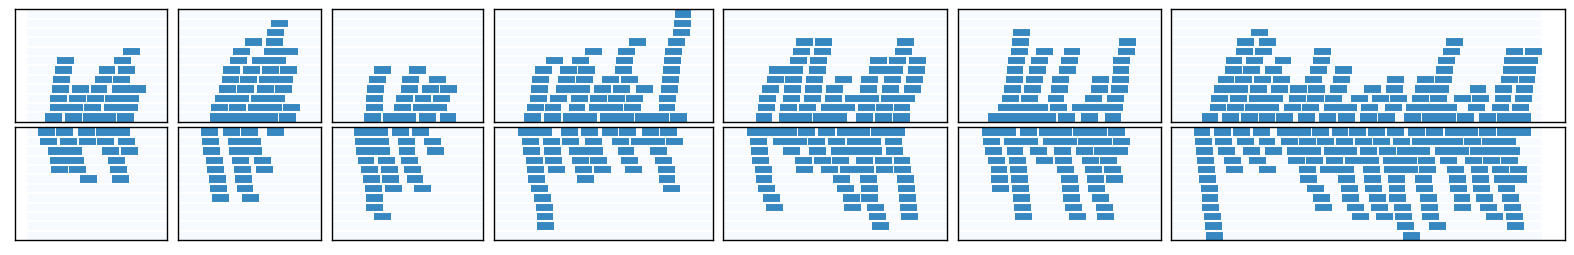

In [564]:
#plus, minus = proto_viz('num_pegRNAs')

#max_pegs = max(proto_df['num_pegRNAs'])
max_pegs = 1.5

fig, ax = plt.subplots(2,len(bounds), figsize=(20,3), width_ratios = wr)
#cbar_ax = fig.add_axes([.91, .3, .03, .4])

for i, val in enumerate(bounds):
    g = sns.heatmap(plus[::-1], cmap='Blues', ax=ax[0][i], vmax = max_pegs, yticklabels=False, xticklabels=False, cbar_ax=None)
    ax[0][i].hlines(list(range(len(plus)))[1:], *ax[0][i].get_xlim(), color='white')
    ax[0][i].set_xlim(val[0], val[1])

    g2 = sns.heatmap(minus, cmap='Blues', ax=ax[1][i], vmax=max_pegs, cbar=False, yticklabels=False,xticklabels=False)
    ax[1][i].set_xlim(val[0], val[1])
    ax[1][i].hlines(list(range(len(minus)))[1:], *ax[1][i].get_xlim(), color='white')

    for _, spine in g.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)
    for _, spine in g2.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)

#ax[0][5].set_title('Number of pegRNAs per protospacer', fontsize=15)
plt.subplots_adjust(wspace=.05, hspace=.05)
fig.savefig('tiling.png', dpi=400)

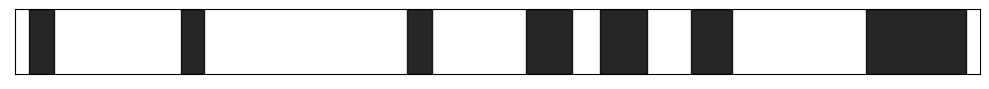

In [568]:
start_end_cds_recentered = []
buffer = 50
for k in start_end_cds:
    h = []
    for j in k:
        h.append(j-127786149+buffer)
    start_end_cds_recentered.append(h)

start_end_cds_recentered

amp_locs = start_end_cds_recentered

mat1 = np.zeros(3441+50)

fig, ax = plt.subplots(figsize=(10,1))

for i in amp_locs:

    ax.axvspan(i[0],i[1], alpha=0.85, color='black')

ax.set_xlim(0,3441+50)
ax.set_yticks([])
ax.set_xticks([])
ax.tick_params(axis='both', which='major', labelsize=15)
#ax.set_xlabel('Genome Coordinate (Re-centered)', fontsize=15)

fig.tight_layout()
#fig.savefig('exon_introns_cdk9.pdf')

In [555]:
complex_list = []
mut_aa_list = []
wt_aa_list = []
codon_list = []
for i, val in edit_outcomes.iterrows():
    hg = val['HGVSp']
    if '_' in hg:
        complex_list.append(True)
        mut_aa_list.append(None)
        wt_aa_list.append(None)
        codon_list.append(None)
    else:
        complex_list.append(False)
        if hg !='WT':
            mut_aa_list.append(hg[-1])
            wt_aa_list.append(hg[0])
            codon_list.append(int(hg[1:-1]))
        elif hg=='WT':
            mut_aa_list.append(None)
            wt_aa_list.append(None)
            codon_list.append(None)


edit_outcomes['Complex'] = complex_list
edit_outcomes['MUT_AA'] = mut_aa_list 
edit_outcomes['WT_AA'] = wt_aa_list
edit_outcomes['Codon'] = codon_list

In [556]:
#edit_outcomes.to_csv('simulated_edit_outcomes.csv', index=False)

In [558]:
e = edit_outcomes[edit_outcomes['Complex']==False]
e = e[e['HGVSp']!='WT']
e

,gRNA_id,edit,Editor,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,...,strand,CDS_hit,ABE_amenable,CBE_amenable,HGVSp,potential_splice,Complex,MUT_AA,WT_AA,Codon
0,gRNA_1,GCCGT,ABE,GCGGCCATGGCAAAGCAGTA,1,127786143,127786162,CG,127786163,127786164,...,+,True,True,True,M1V,True,False,V,M,1.0
2,gRNA_2,GGCAG,ABE,CATGGCAAAGCAGTACGACT,1,127786148,127786167,CG,127786168,127786169,...,+,True,True,True,K3E,False,False,E,K,3.0
3,gRNA_2,GGCGG,ABE,CATGGCAAAGCAGTACGACT,1,127786148,127786167,CG,127786168,127786169,...,+,True,True,True,K3E,False,False,E,K,3.0
5,gRNA_3,GCAGA,ABE,ATGGCAAAGCAGTACGACTC,1,127786149,127786168,GG,127786169,127786170,...,+,True,True,True,K3E,False,False,E,K,3.0
6,gRNA_3,GCAAG,ABE,ATGGCAAAGCAGTACGACTC,1,127786149,127786168,GG,127786169,127786170,...,+,True,True,True,K3R,False,False,R,K,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,gRNA_691,TGCGC,CBE,AGACGCGCTCAAACTCCGTC,7,127789538,127789519,TG,127789517,127789516,...,-,True,False,True,V371I,False,False,I,V,371.0
951,gRNA_691,CGTGC,CBE,AGACGCGCTCAAACTCCGTC,7,127789538,127789519,TG,127789517,127789516,...,-,True,False,True,R370H,False,False,H,R,370.0
954,gRNA_691,TGCGT,CBE,AGACGCGCTCAAACTCCGTC,7,127789538,127789519,TG,127789517,127789516,...,-,True,False,True,V371I,False,False,I,V,371.0
955,gRNA_691,CGTGT,CBE,AGACGCGCTCAAACTCCGTC,7,127789538,127789519,TG,127789517,127789516,...,-,True,False,True,R370H,False,False,H,R,370.0


<BarContainer object of 342 artists>

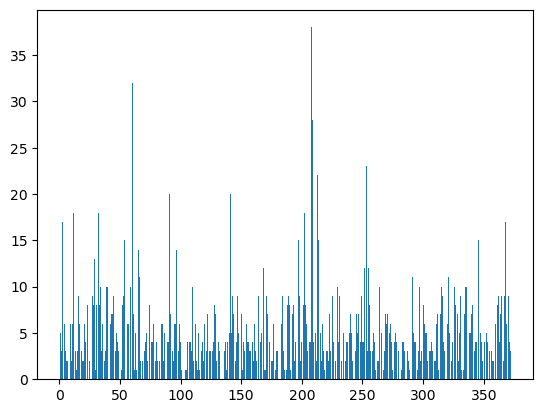

In [562]:
u, c= np.unique(e['Codon'], return_counts=True)
plt.bar(u,c)

In [589]:
e_cbe = e[e['Editor']=='CBE']
e_abe = e[e['Editor']=='ABE']


In [570]:
len(WT)

372

In [571]:
e['Codon']

0        1.0
2        3.0
3        3.0
5        3.0
6        3.0
       ...  
950    371.0
951    370.0
954    371.0
955    370.0
957    371.0
Name: Codon, Length: 1887, dtype: float64

In [574]:
#also generate a mutation matrix (see p53 stuff for visualizaiton)

uniq_aa = ['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y','*',]

dict_aa = dict(zip(uniq_aa,list(range(21))))
mat = np.zeros((21,372))

for i, val in e.iterrows():
    m = str(val['MUT_AA'])
    m_idx = dict_aa[m]

    codon = int(val['Codon'])-1

    mat[m_idx][codon]+=1


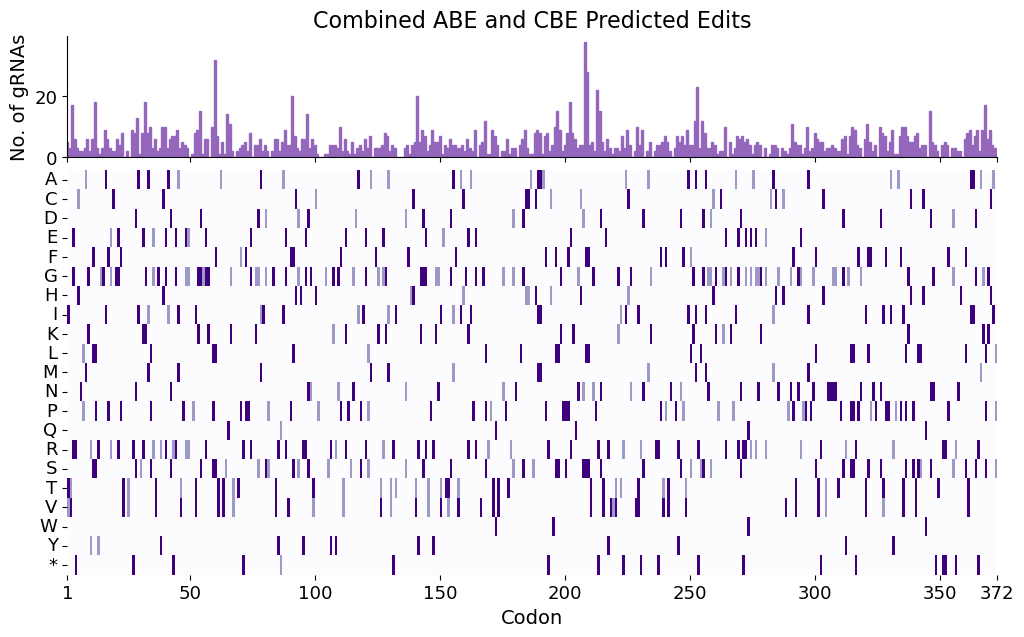

In [587]:
#and plotting the results
fig, ax = plt.subplots(2,1, figsize=(12,7), height_ratios=[3, 10,], sharex=True)
g = sns.heatmap(mat, cmap='Purples', cbar=False, ax=ax[1], vmax=2)


uniq_aa2 = uniq_aa

#ax.set_yticks(range(1,22), rotation=0)
#ax[1].set_yticks(range(len(uniq_aa)), rotation=0)
totals = np.sum(mat,axis=0) 
ax[0].bar(range(372), totals, color='tab:purple', edgecolor='tab:purple')
#ax[0].plot(range(393), totals)

ax[1].set_xticks([0,49,99,149,199,249,299,349,372])
ax[1].set_xticklabels([1,50,100,150,200,250,300,350, 372], rotation=0)


ax[1].set_yticklabels(uniq_aa, rotation=0)
ax[0].tick_params(axis='both', which='major', labelsize=13)


ax[1].tick_params(axis='both', which='major', labelsize=13)
ax[1].set_xlabel('Codon', fontsize=14)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].set_ylabel('No. of gRNAs', fontsize=14)
#ax[0].set_yticks([0,100,200,300], fontsize=14)
#ax[0].set_yticklabels(['',100,200,300], fontsize=14)

#fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(hspace=0.05)
ax[0].set_title('Combined ABE and CBE Predicted Edits', fontsize=16)

#fig.tight_layout()
#fig.savefig('combined_ABE_CBE.pdf')

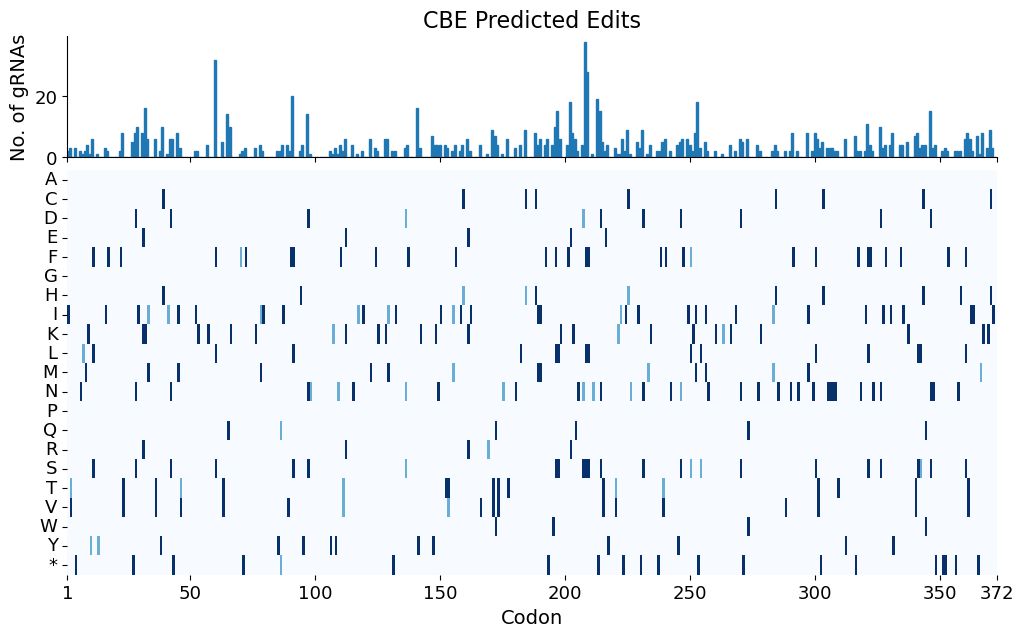

In [594]:
#also generate a mutation matrix (see p53 stuff for visualizaiton)

uniq_aa = ['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y','*',]

dict_aa = dict(zip(uniq_aa,list(range(21))))
mat = np.zeros((21,372))

for i, val in e_cbe.iterrows():
    m = str(val['MUT_AA'])
    m_idx = dict_aa[m]

    codon = int(val['Codon'])-1

    mat[m_idx][codon]+=1

#and plotting the results
fig, ax = plt.subplots(2,1, figsize=(12,7), height_ratios=[3, 10,], sharex=True)
g = sns.heatmap(mat, cmap='Blues', cbar=False, ax=ax[1], vmax=2)


uniq_aa2 = uniq_aa

#ax.set_yticks(range(1,22), rotation=0)
#ax[1].set_yticks(range(len(uniq_aa)), rotation=0)
totals = np.sum(mat,axis=0) 
ax[0].bar(range(372), totals, color='tab:blue', edgecolor='tab:blue')
#ax[0].plot(range(393), totals)

ax[1].set_xticks([0,49,99,149,199,249,299,349,372])
ax[1].set_xticklabels([1,50,100,150,200,250,300,350, 372], rotation=0)


ax[1].set_yticklabels(uniq_aa, rotation=0)
ax[0].tick_params(axis='both', which='major', labelsize=13)


ax[1].tick_params(axis='both', which='major', labelsize=13)
ax[1].set_xlabel('Codon', fontsize=14)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].set_ylabel('No. of gRNAs', fontsize=14)
#ax[0].set_yticks([0,100,200,300], fontsize=14)
#ax[0].set_yticklabels(['',100,200,300], fontsize=14)

#fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(hspace=0.05)
ax[0].set_title('CBE Predicted Edits', fontsize=16)


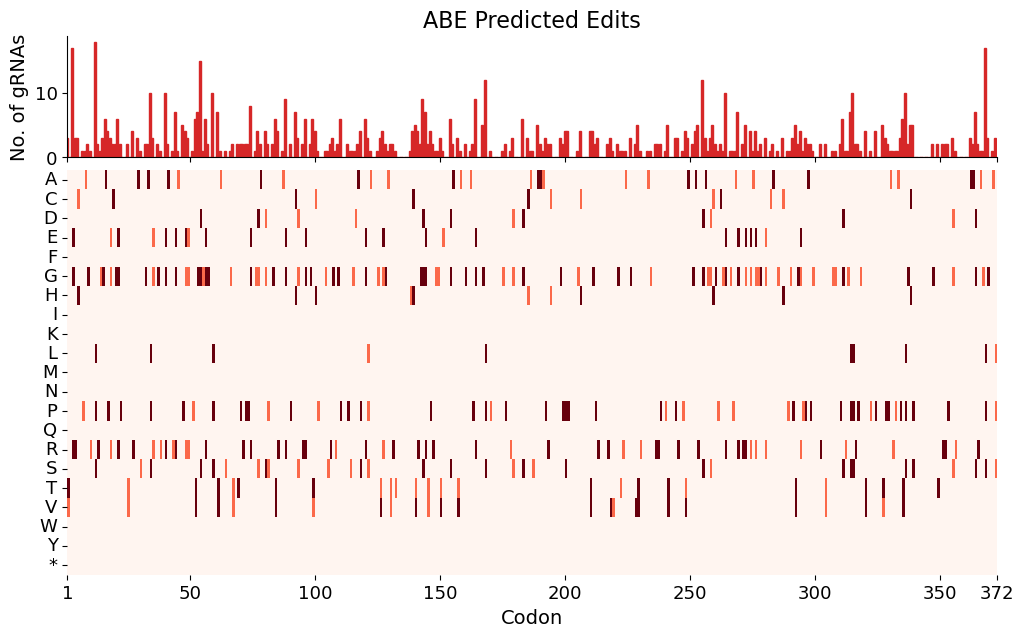

In [595]:
#also generate a mutation matrix (see p53 stuff for visualizaiton)

uniq_aa = ['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y','*',]

dict_aa = dict(zip(uniq_aa,list(range(21))))
mat = np.zeros((21,372))

for i, val in e_abe.iterrows():
    m = str(val['MUT_AA'])
    m_idx = dict_aa[m]

    codon = int(val['Codon'])-1

    mat[m_idx][codon]+=1

#and plotting the results
fig, ax = plt.subplots(2,1, figsize=(12,7), height_ratios=[3, 10,], sharex=True)
g = sns.heatmap(mat, cmap='Reds', cbar=False, ax=ax[1], vmax=2)


uniq_aa2 = uniq_aa

#ax.set_yticks(range(1,22), rotation=0)
#ax[1].set_yticks(range(len(uniq_aa)), rotation=0)
totals = np.sum(mat,axis=0) 
ax[0].bar(range(372), totals, color='tab:red', edgecolor='tab:red')
#ax[0].plot(range(393), totals)

ax[1].set_xticks([0,49,99,149,199,249,299,349,372])
ax[1].set_xticklabels([1,50,100,150,200,250,300,350, 372], rotation=0)


ax[1].set_yticklabels(uniq_aa, rotation=0)
ax[0].tick_params(axis='both', which='major', labelsize=13)


ax[1].tick_params(axis='both', which='major', labelsize=13)
ax[1].set_xlabel('Codon', fontsize=14)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].set_ylabel('No. of gRNAs', fontsize=14)
#ax[0].set_yticks([0,100,200,300], fontsize=14)
#ax[0].set_yticklabels(['',100,200,300], fontsize=14)

#fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(hspace=0.05)
ax[0].set_title('ABE Predicted Edits', fontsize=16)


In [599]:
len(np.unique(e_cbe['Codon']))

212

In [600]:
len(np.unique(e_abe['Codon']))

257

In [605]:
both = 0
abe_only = 0
cbe_only = 0

for i in np.unique(e_abe['Codon']):
    if i in np.unique(e_cbe['Codon']):
        both+=1
    else:
        abe_only+=1

for i in np.unique(e_cbe['Codon']):
    if i not in np.unique(e_abe['Codon']):
        cbe_only+=1
   

In [606]:
both + abe_only + cbe_only

342

In [628]:
ki = [106, 107, 25, 167, 33, 27, 166, 30, 46, 79, 156, 109, 108]
kb = [107, 156, 105, 106, 103, 79, 48, 166, 46, 167, 153, 25, 109]


uniq_codons = np.unique(e['Codon'])

count_ki = 0
count_kb = 0
for i in ki: 
    if i in uniq_codons:
        count_ki+=1
    else:
        print(f'KI : {i}')

for i in kb:
    if i in uniq_codons:
        count_kb +=1
    else:
        print(f'Kb : {i}')

print(f'KI: {count_ki}/{len(ki)}')
print(f'KB: {count_kb}/{len(kb)}')

Kb : 103
KI: 13/13
KB: 12/13


In [629]:
WT[103-1]

'F'